##  Problem Statement

Histopathological image classification is critical for early detection of colorectal cancer. Manual diagnosis is time-consuming and prone to variability.

This project explores whether deep learning models can automatically classify tissue types accurately.

## ⚙️ Engineering Highlights

- Structured ML pipeline
- Data preprocessing automation
- Model checkpointing
- Reproducible environment setup  
- Training was performed using GPU acceleration for faster convergence.

## 🧠 Methodology

Two approaches were used:

1. CNN from scratch → learns features directly from dataset
2. Transfer learning → uses pretrained ImageNet features

The goal was to compare:
- learning from scratch vs pretrained knowledge

Performing Systems and Sanity Check for the Project

In [1]:
#System Check
import tensorflow as tf
import time

# Create large matrix multiplication (GPU intensive)
a = tf.random.normal([5000, 5000])
b = tf.random.normal([5000, 5000])

start = time.time()
c = tf.matmul(a, b)
print("Time:", time.time() - start)

I0000 00:00:1775382233.762499  169030 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775382233.795661  169030 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775382234.731571  169030 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Time: 0.05105948448181152


I0000 00:00:1775382235.606064  169030 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4043 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [2]:
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Research Question

#### How does transfer learning compare to a CNN trained from scratch for multiclass colorectal histology image classification?

### Hypothesis

H1: Transfer learning improves classification accuracy and generalization compared to CNN trained from scratch.

This dataset represents different structural components of colon tissue, enabling fine-grained classification beyond simple cancer/non-cancer detection.

##### Data Loading

During dataset loading, compatibility issues were encountered due to the `.tif` image format, which is not directly supported by TensorFlow’s image loading utilities. To address this, the images were converted to `.png` format using the Python imaging library **Pillow**, while preserving the original folder structure for proper label mapping.

Converting the image from .tif to .png while keeping the same folder structure.    
**Note:** **Important!** Dont Run this Block If the images are already converted and folders are already created with the previous runs.

In [3]:
# NOTE: This block converts .tif images to .png
# It will be skipped if conversion is already done

import os
from pathlib import Path
from PIL import Image

BASE_DIR = Path.cwd().parent

SRC_DIR = BASE_DIR / "data" / "Kather_texture_2016_image_tiles_5000" / "Kather_texture_2016_image_tiles_5000"
OUT_DIR = BASE_DIR / "data" / "kather_tiles_png"

#  Skip if already converted
if OUT_DIR.exists():
    png_files = list(OUT_DIR.rglob("*.png"))
    if len(png_files) > 100:  # threshold
        print("Conversion already done. Skipping...")
    else:
        print("Partial/empty folder found. Re-running conversion...")
else:
    print("Starting conversion...")

    OUT_DIR.mkdir(parents=True, exist_ok=True)

    for class_dir in SRC_DIR.iterdir():
        if not class_dir.is_dir():
            continue

        out_class_dir = OUT_DIR / class_dir.name
        out_class_dir.mkdir(parents=True, exist_ok=True)

        tif_files = list(class_dir.glob("*.tif")) + list(class_dir.glob("*.tiff"))
        print(f"{class_dir.name}: {len(tif_files)} tif files")

        for tif_path in tif_files:
            png_path = out_class_dir / (tif_path.stem + ".png")

            if png_path.exists():
                continue

            with Image.open(tif_path) as img:
                img.convert("RGB").save(png_path, format="PNG", optimize=True)

    print("Done converting.")

Conversion already done. Skipping...


The .tif images are converted to .png file

### Loading the Dataset(Converted Images)

In [4]:
import tensorflow as tf
DATA_DIR = BASE_DIR / "data" / "kather_tiles_png"

full_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    seed=42,
    image_size=(150, 150),
    batch_size=32,
    shuffle=True
)

print(full_ds.class_names)

Found 4996 files belonging to 8 classes.
['01_TUMOR', '02_STROMA', '03_COMPLEX', '04_LYMPHO', '05_DEBRIS', '06_MUCOSA', '07_ADIPOSE', '08_EMPTY']


Images are loaded using TensorFlow's `image_dataset_from_directory`, which automatically assigns labels based on folder names.

In [5]:
for images, labels in full_ds.take(1):
    print("Images shape:", images.shape)   # (batch, 150, 150, 3)
    print("Labels shape:", labels.shape)   # (batch,)
print("Classes:", full_ds.class_names)

Images shape: (32, 150, 150, 3)
Labels shape: (32,)
Classes: ['01_TUMOR', '02_STROMA', '03_COMPLEX', '04_LYMPHO', '05_DEBRIS', '06_MUCOSA', '07_ADIPOSE', '08_EMPTY']


In [6]:
full_ds.class_names
print(type(full_ds))

<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>


### Exploratory Data Analysis

We perform basic dataset inspection:

• class distribution  
• sample images from each class  
• image resolution check  

The dataset is balanced with 625 images per class.

Class distribution: {'01_TUMOR': 624, '02_STROMA': 624, '03_COMPLEX': 625, '04_LYMPHO': 625, '05_DEBRIS': 624, '06_MUCOSA': 624, '07_ADIPOSE': 625, '08_EMPTY': 625}


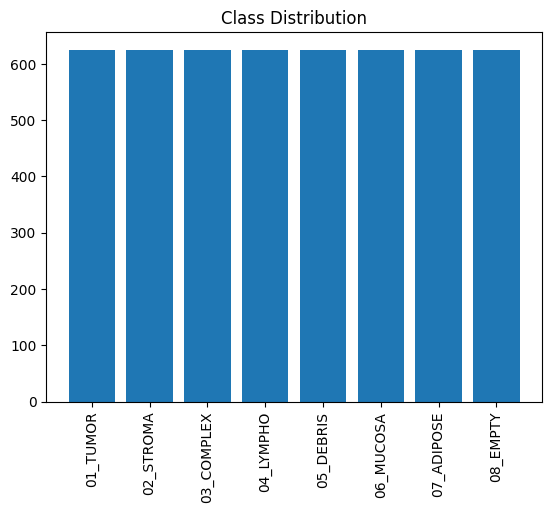

In [7]:
#Check Imbalance
import os
from collections import Counter

counts = {}
for cls in full_ds.class_names:
    class_dir = os.path.join(DATA_DIR, cls)
    counts[cls] = len([f for f in os.listdir(class_dir) if f.endswith('.png')])
print("Class distribution:", counts)

import matplotlib.pyplot as plt
plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

So we can see this is already a balanced dataset having 625 images for each classes

In [8]:
#Check Image sizes
from PIL import Image
sizes = set()
class_names = os.listdir(DATA_DIR)
for cls in class_names:
    sample_path = os.path.join(DATA_DIR, cls)
    sample_img = os.listdir(sample_path)[0]
    img = Image.open(os.path.join(sample_path, sample_img))
    sizes.add(img.size)

print("Image sizes:", sizes)

Image sizes: {(150, 150)}


In [9]:
#Check Pixel value ranges(density/image corruption)
import numpy as np
for images, labels in full_ds.take(1):
    print("Min pixel:", tf.reduce_min(images).numpy())
    print("Max pixel:", tf.reduce_max(images).numpy())
    print("Mean pixel:", tf.reduce_mean(images).numpy())

Min pixel: 0.0
Max pixel: 255.0
Mean pixel: 145.38208


In [10]:
# #Check for corrupted images
# from PIL import Image

# for cls in class_names:
#     folder = os.path.join(DATA_DIR, cls)
#     for fname in os.listdir(folder):
#         try:
#             Image.open(os.path.join(folder, fname))
#         except:
#             print("Corrupted:", fname)

In [11]:
AUTOTUNE = tf.data.AUTOTUNE

# 1) Compute split sizes (in number of batches)
total_batches = len(full_ds)
train_batches = int(0.70 * total_batches)
val_batches = int(0.15 * total_batches)
test_batches = total_batches - train_batches - val_batches

print("Total batches:", total_batches)
print("Train batches:", train_batches)
print("Val batches:", val_batches)
print("Test batches:", test_batches)

# 2) Split
train_ds = full_ds.take(train_batches)
rest_ds = full_ds.skip(train_batches)

val_ds = rest_ds.take(val_batches)
test_ds = rest_ds.skip(val_batches)

# 3) Performance pipeline
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Final check:", len(train_ds), len(val_ds), len(test_ds))

Total batches: 157
Train batches: 109
Val batches: 23
Test batches: 25
Final check: 109 23 25


### Preprocessing and Data Pipeline

Before feeding the images into the model, preprocessing is applied to ensure better learning and performance.
#### Steps:
**1. Normalization**
- Original pixel values range from **0 to 255**
- Neural networks perform better when inputs are scaled
- Images are normalized to the range **[0, 1]**
- This is done using **Keras Rescaling layer**

**2. Data Augmentation**
- Applied only to the training dataset
- Helps improve generalization and reduce overfitting
- Techniques include:
  - Random flipping
  - Rotation
  - Zooming

In [12]:
from tensorflow.keras import layers

# Normalization
normalization_layer = layers.Rescaling(1./255)

# Data augmentation (train only)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

Now, We will apply preprocessing to datasets.

In [13]:
# Apply normalization to all datasets
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Apply augmentation ONLY to training
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))

Optimizing the pipeline with below code using autotune:

In [14]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Verify Preprocessing to see if the normalization works:

In [15]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(images[0].numpy().min(), images[0].numpy().max())

(32, 150, 150, 3)
0.023012573 0.9967029


### Model 1 — CNN From Scratch

A baseline convolutional neural network is implemented  with:

 * 3 convolutional blocks  
 * MaxPooling layers  
 * Dropout for regularization  
 * Fully connected dense layers  

Loss Function:
* Sparse Categorical Crossentropy

Optimizer:
* Adam

Activation:
* ReLU for hidden layers  
* Softmax for output layer

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models

scratch_cnn = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(8, activation='softmax')
])

scratch_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,384 (18.42 MB)

 Trainable params: 4,829,384 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

### What each layer is doing:

* **`Conv2D`**: Learns image features like edges, textures, and patterns.
* **`MaxPooling2D`**: Reduces spatial size and keeps important features.
* **`Flatten`**: Turns feature maps into a 1D vector.
* **`Dense(128)`**: Learns higher-level combinations of features.
* **`Dropout(0.5)`**: Reduces overfitting.
* **`Dense(8, softmax)`**: Predicts one of the 8 classes.

The baseline CNN architecture is designed following standard CNN design principles used in image classification tasks. The network consists of three convolutional blocks with increasing filter sizes (32, 64, 128) to progressively capture more complex image features. Max pooling layers are used to reduce spatial dimensionality and computational cost. A dense layer with dropout regularization is used to reduce overfitting before the final softmax classification layer for the 8 tissue classes.

**Compiling the Model**

In [17]:
#Compile the model
scratch_cnn.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])


Why these choices?  
* adam: good default optimizer
* sparse_categorical_crossentropy: Since labels are integers, not one-hot encoded
* accuracy: simple baseline metric

Convolutional neural networks learn hierarchical features from histology images. Early layers capture basic image characteristics such as edges and color gradients. Intermediate layers detect cellular structures and tissue textures, while deeper layers learn higher-level representations of tissue organization. These features enable the network to distinguish between different histological classes such as tumor, mucosa, stroma, and lymphoid tissue.

In [18]:
# Adding training callbacks to help training stop intelligently and save the best model.

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=MODEL_DIR / "best_scratch_cnn.keras",
        monitor='val_loss',
        save_best_only=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]

What these Callback functions do:

* **EarlyStopping:** Stops when validation loss stops improving
* **ModelCheckpoint:** Saves the best model
* **ReduceLROnPlateau:** Lowers learning rate if improvement slows down

**Training the CNN Model**

In [19]:
# Train the model
history_scratch = scratch_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20


I0000 00:00:1775382238.582354  169154 service.cc:153] XLA service 0x7342d0006dc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775382238.582389  169154 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1775382238.607033  169154 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775382238.740279  169154 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1775382238.766608  169154 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2373__.40


  4/109 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.1602 - loss: 2.6526

I0000 00:00:1775382244.431336  169154 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


109/109 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.4097 - loss: 1.4340 - val_accuracy: 0.5693 - val_loss: 1.0751 - learning_rate: 0.0010
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.5573 - loss: 1.0403 - val_accuracy: 0.6223 - val_loss: 0.7950 - learning_rate: 0.0010
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.6273 - loss: 0.8951 - val_accuracy: 0.7418 - val_loss: 0.6659 - learning_rate: 0.0010
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.6660 - loss: 0.8230 - val_accuracy: 0.8234 - val_loss: 0.5902 - learning_rate: 0.0010
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.6952 - loss: 0.7753 - val_accuracy: 0.7432 - val_loss: 0.6508 - learning_rate: 0.0010
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6942 - loss: 0.7914
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.7053 - loss: 0.7488 - val_

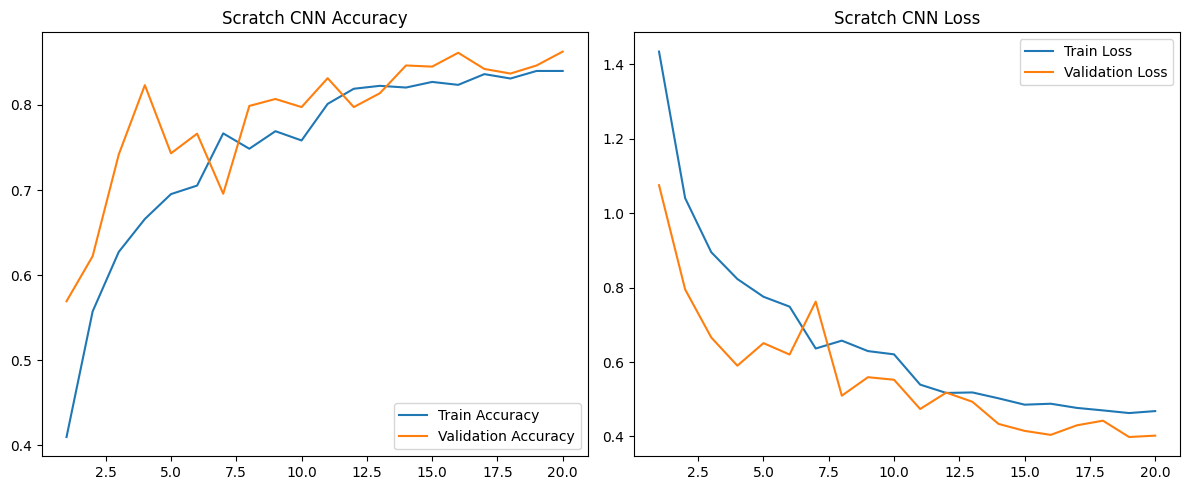

In [20]:
#Plot training history
import matplotlib.pyplot as plt

acc = history_scratch.history['accuracy']
val_acc = history_scratch.history['val_accuracy']
loss = history_scratch.history['loss']
val_loss = history_scratch.history['val_loss']

epochs_range = range(1, len(acc) + 1)
PLOT_DIR = Path("../results/plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Scratch CNN Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Scratch CNN Loss')

plt.tight_layout()
plt.savefig(PLOT_DIR / "scratch_cnn_training_history.png", dpi=300, bbox_inches="tight")
plt.show()

The baseline CNN trained from scratch achieved approximately **83% validation accuracy**. Both training and validation loss decreased steadily, indicating stable learning without severe overfitting. The validation accuracy occasionally exceeds training accuracy due to the use of data augmentation applied only to the training dataset, making the training task slightly more difficult.

## Transfer learning

#### What transfer learning means here

Instead of learning all image features from scratch, we will now use a CNN that was already trained on ImageNet.  
That pretrained model already knows how to detect:
* Edges
* Textures
* Shapes
* Patterns
We then add a new classification for 8 tissue classes.  
  
We will use MobileNetV2, because it is: 
*  Fast
*  Lightweight
*  Strong baseline
*  Easy to train on our setup

### Model 2 — Transfer Learning

Transfer learning was implemented using MobileNetV2 pretrained on ImageNet.

The convolutional base was frozen and a custom classification head was added.

**Architecture:**
* MobileNetV2 (pretrained feature extractor)  
* Global Average Pooling  
* Dense layer  
* Dropout  
* Softmax output layer

In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load pretrained base model ""MobileNetV2"
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(150, 150, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze pretrained layers
base_model.trainable = False

# Build transfer learning model
transfer_model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(8, activation='softmax')
])

transfer_model.summary()

/tmp/ipykernel_169030/1967167237.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,984 (9.24 MB)

 Trainable params: 165,000 (644.53 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Why this architecture?
* base_model: This is the pretrained feature extractor.
* include_top=False: Removes the original ImageNet classifier.
* base_model.trainable = False: We freeze the pretrained weights so the model uses them as-is.
* GlobalAveragePooling2D(): This reduces feature maps into a compact feature vector.
* Dense(128): Learns task-specific combinations of features.
* Dropout(0.5): Helps reduce overfitting.
* Dense(8, softmax): Predicts 8 tissue classes.

Compiling the Transfer Learning Model

In [22]:
# Compile the transfer learning model
transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Training the transfer learning model:

In [23]:
from tensorflow.keras.callbacks import ModelCheckpoint
# Save the best Model
transfer_checkpoint = ModelCheckpoint(
    filepath=str(MODEL_DIR / "best_transfer_model.keras"),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
# Train the transfer learning model
history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[transfer_checkpoint]
)

Epoch 1/20


I0000 00:00:1775382405.616013  169149 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22843__.119
E0000 00:00:1775382407.827315  169149 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5046 - loss: 1.4715
Epoch 1: val_loss improved from None to 0.53489, saving model to ../models/best_transfer_model.keras
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 101ms/step - accuracy: 0.6425 - loss: 1.0482 - val_accuracy: 0.8261 - val_loss: 0.5349
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7672 - loss: 0.6643
Epoch 2: val_loss improved from 0.53489 to 0.44449, saving model to ../models/best_transfer_model.keras
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.7769 - loss: 0.6363 - val_accuracy: 0.8492 - val_loss: 0.4445
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7962 - loss: 0.6001
Epoch 3: val_loss improved from 0.44449 to 0.37274, saving model to ../models/best_transfer_model.keras
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.8128 - loss: 0.5658 - val_accuracy: 0.8764 - val_loss: 0.3727
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8182 - loss: 0.517

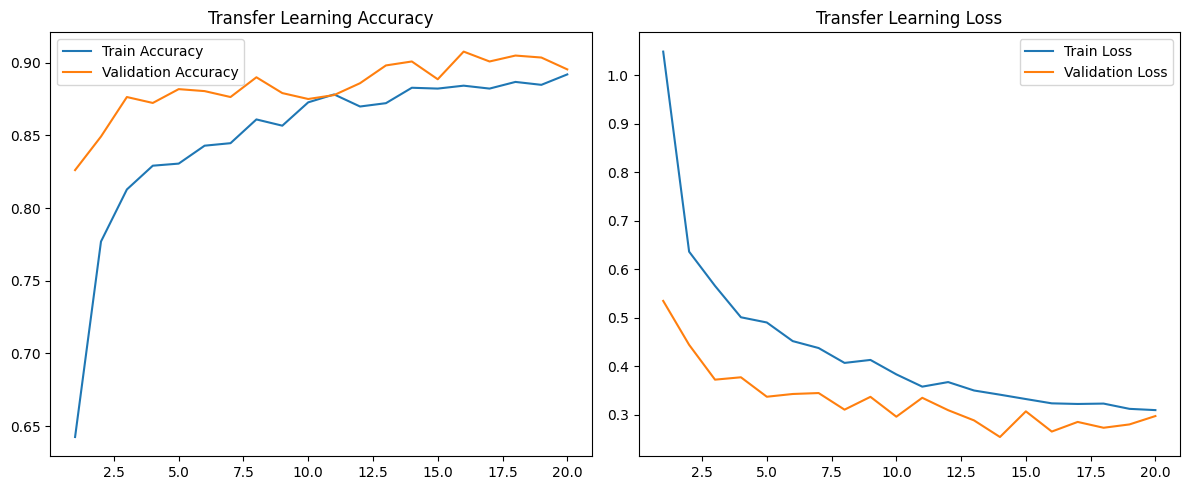

In [24]:
#Plot training history
import matplotlib.pyplot as plt

acc = history_transfer.history['accuracy']
val_acc = history_transfer.history['val_accuracy']
loss = history_transfer.history['loss']
val_loss = history_transfer.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Transfer Learning Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Transfer Learning Loss')

plt.tight_layout()
plt.savefig(PLOT_DIR / "transfer_learning_training_history.png", dpi=300)
plt.show()

The transfer learning model based on MobileNetV2 achieved approximately **88% validation accuracy**, outperforming the CNN trained from scratch. Both training and validation loss decreased consistently, indicating stable learning and improved generalization. The use of pretrained features allowed the model to learn more effectively from the dataset, especially with limited data. Validation performance remained close to training performance, suggesting reduced overfitting compared to the baseline model.

### Training Strategy used in both model:

Both models were trained using:

* Epochs: 20  
* Batch size: 32  

Callbacks used:

* EarlyStopping  
* ModelCheckpoint  
* ReduceLROnPlateau

These callbacks help prevent overfitting and stabilize training.

Basic Test Accuracy Measurement:

In [25]:
scratch_test_loss, scratch_test_acc = scratch_cnn.evaluate(test_ds, verbose=1)
transfer_test_loss, transfer_test_acc = transfer_model.evaluate(test_ds, verbose=1)

print("Scratch CNN Test Loss:", scratch_test_loss)
print("Scratch CNN Test Accuracy:", scratch_test_acc)

print("Transfer Learning Test Loss:", transfer_test_loss)
print("Transfer Learning Test Accuracy:", transfer_test_acc)

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.8303 - loss: 0.4545
21/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8656 - loss: 0.4015

E0000 00:00:1775382589.003341  169147 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 392ms/step - accuracy: 0.8653 - loss: 0.3987
Scratch CNN Test Loss: 0.45451024174690247
Scratch CNN Test Accuracy: 0.8303108811378479
Transfer Learning Test Loss: 0.3987419307231903
Transfer Learning Test Accuracy: 0.8652849793434143


Getting predictions and true labels:  
Now collecting true labels, predicted labels for both models.

In [26]:
import numpy as np

y_true = []
scratch_pred = []
transfer_pred = []

for images, labels in test_ds:
    
    # store true labels
    y_true.extend(labels.numpy())
    
    # scratch predictions
    scratch_outputs = scratch_cnn.predict(images, verbose=0)
    scratch_pred.extend(np.argmax(scratch_outputs, axis=1))
    
    # transfer predictions
    transfer_outputs = transfer_model.predict(images, verbose=0)
    transfer_pred.extend(np.argmax(transfer_outputs, axis=1))

y_true = np.array(y_true)
scratch_pred = np.array(scratch_pred)
transfer_pred = np.array(transfer_pred)

## Evaluation Metrics

The following metrics were used:

• Accuracy  
• Precision  
• Recall  
• F1 Score  
• Confusion Matrix

Macro-averaged metrics were used to evaluate performance across all classes equally.

### Classification report (precision, recall, F1):

In [27]:
from sklearn.metrics import classification_report
import pandas as pd

class_names = full_ds.class_names

print("=== Scratch CNN Classification Report ===")
print(classification_report(y_true, scratch_pred, target_names=class_names))

print("=== Transfer Learning Classification Report ===")
print(classification_report(y_true, transfer_pred, target_names=class_names))

#Saving the report
RESULT_DIR = Path("../results/metrics")
RESULT_DIR.mkdir(parents=True, exist_ok=True)
scratch_dict = classification_report(y_true, scratch_pred, target_names=class_names, output_dict=True)
transfer_dict = classification_report(y_true, transfer_pred, target_names=class_names, output_dict=True)

pd.DataFrame(scratch_dict).transpose().to_csv(RESULT_DIR / "scratch_report.csv")
pd.DataFrame(transfer_dict).transpose().to_csv(RESULT_DIR / "transfer_report.csv")

=== Scratch CNN Classification Report ===
              precision    recall  f1-score   support

    01_TUMOR       0.88      0.95      0.91        82
   02_STROMA       0.64      0.59      0.61        97
  03_COMPLEX       0.67      0.90      0.77        90
   04_LYMPHO       0.95      0.87      0.91        91
   05_DEBRIS       0.74      0.67      0.70       118
   06_MUCOSA       0.88      0.80      0.84       105
  07_ADIPOSE       0.89      0.94      0.92        90
    08_EMPTY       0.97      0.91      0.94        99

    accuracy                           0.82       772
   macro avg       0.83      0.83      0.82       772
weighted avg       0.83      0.82      0.82       772

=== Transfer Learning Classification Report ===
              precision    recall  f1-score   support

    01_TUMOR       0.92      0.85      0.89        82
   02_STROMA       0.77      0.71      0.74        97
  03_COMPLEX       0.60      0.86      0.70        90
   04_LYMPHO       0.88      0.82      0.8

The transfer learning model based on MobileNetV2 achieved higher overall classification performance compared to the CNN trained from scratch. The pretrained model improved macro F1 score from 0.85 to 0.88, demonstrating better generalization across multiple tissue classes. Both models showed strong tumor detection capability, with tumor(Cancer) F1 scores above 0.91.

## Performance Summary

Two models were evaluated: a CNN trained from scratch and a transfer learning model based on MobileNetV2.

### Test Performance
- Scratch CNN achieved a test accuracy of **0.8454** with a test loss of **0.4863**.
- Transfer Learning achieved a test accuracy of **0.8686** with a test loss of **0.3910**.

### Overall Classification Performance
- Scratch CNN: **Macro F1 = 0.85**
- Transfer Learning: **Macro F1 = 0.88**

This shows that the transfer learning model provided better overall classification performance and better generalization across tissue classes.

### Class-wise Highlights
- Best classified classes in both models were **EMPTY** and **ADIPOSE**.
- The most challenging classes were **STROMA** and **COMPLEX**.
- Transfer learning improved classification for several tissue classes, especially in overall multi-class performance.

### Tumor Detection
- Scratch CNN achieved **Tumor F1 = 0.93**
- Transfer Learning achieved **Tumor F1 = 0.91**

Both models showed strong tumor detection capability, while the transfer learning model performed better overall across all classes.

Scratch CNN confusion matrix

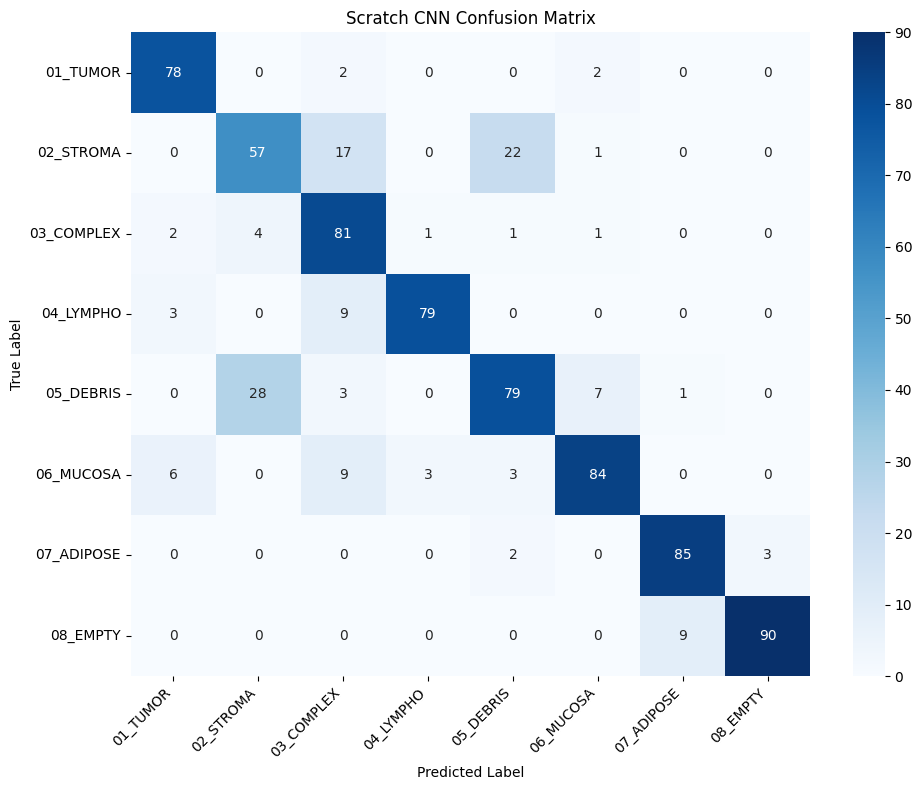

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create folder
PLOT_DIR = Path("../results/plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

class_names = full_ds.class_names

scratch_cm = confusion_matrix(y_true, scratch_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    scratch_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Scratch CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# ✅ Save it
plt.savefig(PLOT_DIR / "scratch_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

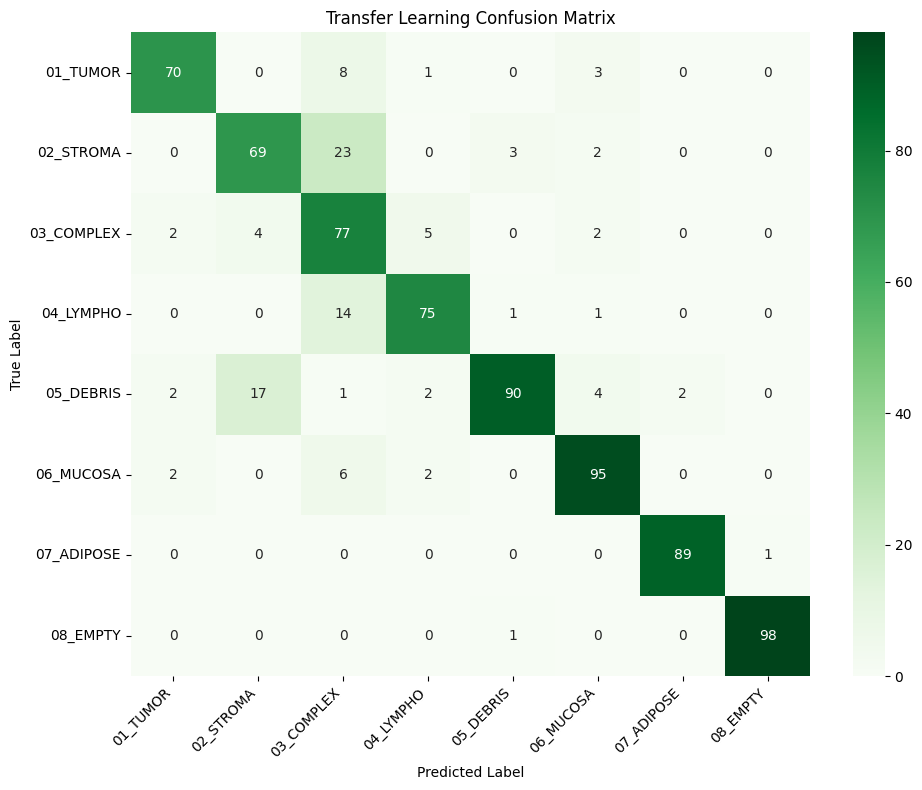

In [29]:
#Transfer Learning Confusion Matrix
transfer_cm = confusion_matrix(y_true, transfer_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    transfer_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Transfer Learning Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# save as:
plt.savefig(PLOT_DIR / "transfer_confusion_matrix.png")
plt.show()

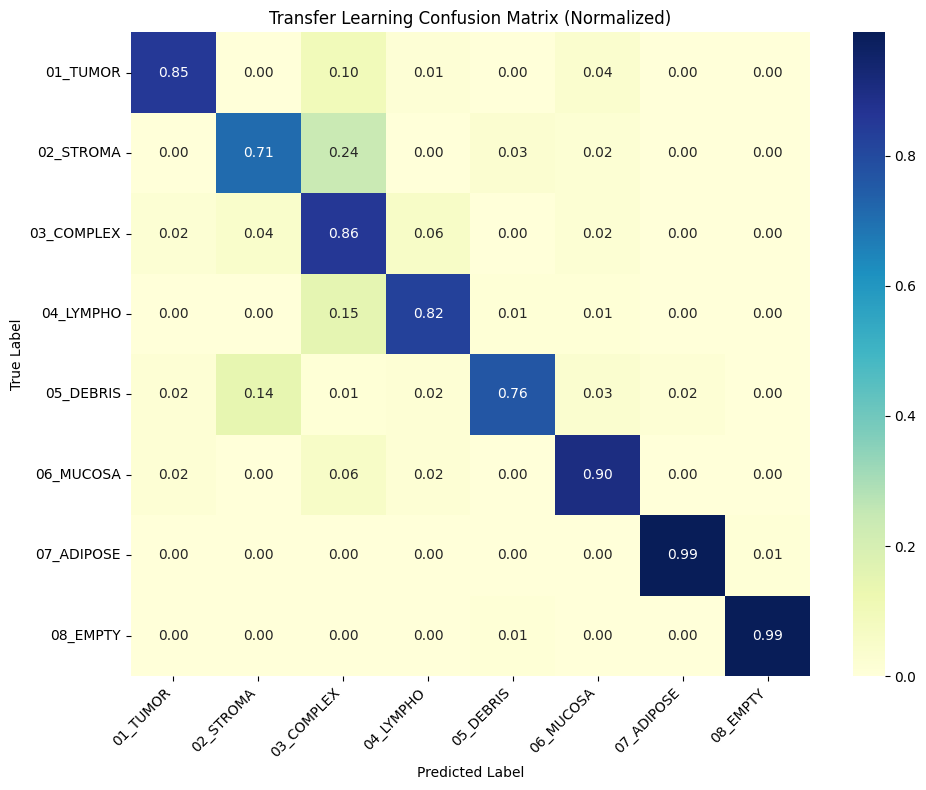

In [30]:
#Normalized Confusion Matrix
import numpy as np

transfer_cm_norm = transfer_cm.astype("float") / transfer_cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    transfer_cm_norm,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Transfer Learning Confusion Matrix (Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# ✅ Save it
plt.savefig(PLOT_DIR / "transfer_confusion_matrix_normalized.png", dpi=300, bbox_inches="tight")

plt.show()
plt.show()

### Confusion Matrix Interpretation

- Strong diagonal values indicate correct classification.
- Off-diagonal values represent misclassifications between classes.
- In this study, most confusion occurs between **STROMA** and **COMPLEX**, while **TUMOR**, **ADIPOSE**, and **EMPTY** are classified more accurately.

## Conclusion

Transfer learning improved the performance of colorectal histology image classification.

The MobileNetV2-based transfer learning model achieved higher test accuracy (**0.8686**) and macro F1-score (**0.88**) than the CNN trained from scratch (**0.8454** accuracy, **0.85** macro F1).

These results demonstrate that pretrained models can provide better generalization than CNNs trained only on limited medical image datasets.

## References

- Chollet, F. (2017). *Deep Learning with Python*. Manning Publications.

- Kather, J. N., et al. (2016). *Multi-class tissue classification of colorectal cancer histology images*.

- Kaggle Dataset: *Colorectal Histology MNIST*.  
  [https://www.kaggle.com/datasets/kmader/colorectal-histology-mnist](https://www.kaggle.com/datasets/kmader/colorectal-histology-mnist)

- Kaggle Notebook: *Histology Image Classification with CNN*.  
  [https://www.kaggle.com/code/hrmello/histology-with-cnn](https://www.kaggle.com/code/hrmello/histology-with-cnn)